In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rajathmc_bag_of_words_meets_bags_of_popcorn__path = kagglehub.dataset_download('rajathmc/bag-of-words-meets-bags-of-popcorn-')
aayushkubba_mask_image_path = kagglehub.dataset_download('aayushkubba/mask-image')

print('Data source import complete.')


100%|██████████| 52.4M/52.4M [00:01<00:00, 29.9MB/s]

Extracting files...


100%|██████████| 327k/327k [00:00<00:00, 884kB/s]

Extracting files...
Data source import complete.


In [ ]:
!ls /root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/

labeledTrainData.tsv  testData.tsv
sampleSubmission.csv  unlabeledTrainData.tsv


In [ ]:
rajathmc_bag_of_words_meets_bags_of_popcorn__path

'/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1'

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/1.complete
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/sampleSubmission.csv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/labeledTrainData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/unlabeledTrainData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/testData.tsv


In [ ]:
train=pd.read_csv("/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/labeledTrainData.tsv",delimiter="\t")
train.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [ ]:
# Sample Review
train["review"][20]

'\\Soylent Green\\" is one of the best and most disturbing science fiction movies of the 70\'s and still very persuasive even by today\'s standards. Although flawed and a little dated, the apocalyptic touch and the environmental premise (typical for that time) still feel very unsettling and thought-provoking. This film\'s quality-level surpasses the majority of contemporary SF flicks because of its strong cast and some intense sequences that I personally consider classic. The New York of 2022 is a depressing place to be alive, with over-population, unemployment, an unhealthy climate and the total scarcity of every vital food product. The only form of food available is synthetic and distributed by the Soylent company. Charlton Heston (in a great shape) plays a cop investigating the murder of one of Soylent\'s most eminent executives and he stumbles upon scandals and dark secrets... The script is a little over-sentimental at times and the climax doesn\'t really come as a big surprise, st

# Text Preprocessing

In [ ]:
!pip install nltk
!pip install beautifulsoup4

In [ ]:
import re
import nltk
from bs4 import BeautifulSoup

In [ ]:
nltk.download("all")


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
stopwords=stopwords.words("english")
wordnet_lemma=WordNetLemmatizer()

In [ ]:
review = train['review'][0]

In [ ]:
review

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [ ]:
def preprocess_text(review):
    # Remove all HTML tags
    review= BeautifulSoup(review).get_text()

    # Remove anything which is not a character
    review=re.sub("[^a-zA-Z]"," ",review)

    #Lowercase
    review=review.lower()

    # Stopword
    review = " ".join([i for i in review.split() if i not in stopwords])


    # Lemmatizer
    review = " ".join([wordnet_lemma.lemmatize(i) for i in review.split()])

    return review

In [ ]:
review=review = train['review'][0]
print("Original Text: ")
print(review)
print("_"*25)
cleaned_review= preprocess_text(review)
print("Cleaner Text: ")
print(cleaned_review)

Original Text: 
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when

In [ ]:
# Apply this function over full dataframe

train['clean_review']=train['review'].apply(preprocess_text)

[('film', 25304),
 ('movie', 19075),
 ('one', 13653),
 ('see', 10907),
 ('make', 10789),

# EDA
## Find out most common words and then Visualize it as well
### For both positive and negative review

In [ ]:
# Give me list of all words frequency
train.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,stuff going moment mj started listening music ...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",classic war world timothy hines entertaining f...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,film start manager nicholas bell giving welcom...
3,3630_4,0,It must be assumed that those who praised this...,must assumed praised film greatest filmed oper...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy wondrously unpretentious explo...


In [ ]:
freq_list={}
for review in train['clean_review'].tolist():
    for word in review.split():
        freq_list[word]=freq_list.get(word,0)+1

In [ ]:
# Give 10 most frequent words

# Sort freq_list dictionary
sorted_freq_words=dict(sorted(freq_list.items(), key= lambda item:item[1], reverse=True))

In [ ]:
from collections import Counter
cnt = Counter(" ".join(train['clean_review'].tolist()).split())


In [ ]:
# Most frequent words in Positive as well as negative reviews

In [ ]:
pos_cnt = Counter(" ".join(train.loc[train['sentiment']==1]['clean_review'].tolist()).split())
neg_cnt = Counter(" ".join(train.loc[train['sentiment']==0]['clean_review'].tolist()).split())

In [ ]:
pos_cnt.most_common(10)

[('film', 24745),
 ('movie', 22657),
 ('one', 14169),
 ('like', 9270),
 ('time', 8346),
 ('good', 7762),
 ('story', 7478),
 ('character', 7073),
 ('well', 6488),
 ('great', 6435)]

In [ ]:
neg_cnt.most_common(10)

[('movie', 29037),
 ('film', 22289),
 ('one', 13572),
 ('like', 11470),
 ('even', 7684),
 ('time', 7613),
 ('good', 7435),
 ('bad', 7394),
 ('character', 7104),
 ('would', 7036)]

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(stopwords=["film","movie"],width=800, height=400, background_color='white').generate(" ".join(train['clean_review'].tolist()))

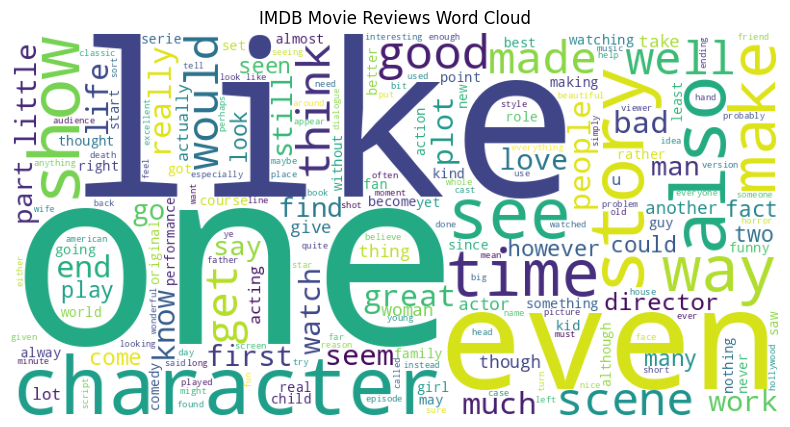

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()

In [ ]:
!wget http://www.stencilry.org/stencils/movies/alice%20in%20wonderland/255fk.jpg

--2026-02-24 15:59:08--  http://www.stencilry.org/stencils/movies/alice%20in%20wonderland/255fk.jpg
Resolving www.stencilry.org (www.stencilry.org)... 15.197.225.128, 3.33.251.168
Connecting to www.stencilry.org (www.stencilry.org)|15.197.225.128|:80... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-24 15:59:08 ERROR 404: Not Found.



In [ ]:
# from PIL import Image
# upvote_mask = np.array(Image.open("/kaggle/input/datasets/aayushkubba/mask-image/upvote.png"))

# wordcloud = WordCloud(stopwords=["film","movie"],width=800, height=400, mask=upvote_mask,background_color='white').generate(" ".join(train['clean_review'].tolist()))

# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud)
# plt.axis('off')
# plt.title("IMDB Movie Reviews Word Cloud")
# plt.show()


# BOW Model

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
train.columns

Index(['id', 'sentiment', 'review', 'clean_review'], dtype='object')

In [ ]:
X=train['clean_review']
y=train['sentiment']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
def create_vector(vectorizer,data):
    '''Pass vectorizer and data'''
    train_vector=vectorizer.transform(data.tolist())
    return train_vector.toarray()

In [ ]:
len(cnt)

66507

In [ ]:
vectorizer=CountVectorizer(max_features=1000)

In [ ]:
vectorizer.fit(X_train.tolist())

CountVectorizer(max_features=1000)

In [ ]:
X_train_vector=create_vector(vectorizer,X_train)
X_test_vector=create_vector(vectorizer,X_test)

In [ ]:
X_train_vector.shape

(16750, 1000)

In [ ]:
X_train_vector[100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,

In [ ]:
X_train[0]

'stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighty maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle message mj feeling towards press also obvious message drug bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fan would say made fan true really nice actual feature film bit finally start minute excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord want mj dead bad beyond mj overheard plan nah joe pesci character ranted wanted people know supplying drug etc dunno maybe hate mj music lot cool thing like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually director hate working one kid let a

In [ ]:
# Create a classifier
# Classical ML
# RF classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
forest=RandomForestClassifier()
forest.fit(X_train_vector,y_train)


y_pred=forest.predict(X_test_vector)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      4105
           1       0.83      0.82      0.83      4145

    accuracy                           0.83      8250
   macro avg       0.83      0.83      0.83      8250
weighted avg       0.83      0.83      0.83      8250



In [ ]:
len(vectorizer.vocabulary_)

1000

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vectorizer = TfidfVectorizer(analyzer="word", tokenizer=nltk.word_tokenize,
    preprocessor=None, stop_words='english', max_features=2000)
tf_vectorizer.fit(X_train.tolist())

X_train_tfvector=create_vector(tf_vectorizer,X_train)
X_test_tfvector=create_vector(tf_vectorizer,X_test)

X_test_tfvector.shape, X_train_tfvector.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


((8250, 2000), (16750, 2000))

In [ ]:
forest=RandomForestClassifier()
forest.fit(X_train_tfvector,y_train)


y_pred=forest.predict(X_test_tfvector)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      4105
           1       0.84      0.82      0.83      4145

    accuracy                           0.83      8250
   macro avg       0.83      0.83      0.83      8250
weighted avg       0.83      0.83      0.83      8250



In [ ]:
# We will start by 9:10
y_pred

array([0, 1, 0, ..., 0, 0, 1])

In [ ]:
# Create a model using Keras using TF-IDF
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

model_ann = Sequential()
# Input layer with the number of features from X_train_tfvector
model_ann.add(Dense(units=128, activation='relu', input_shape=(X_train_tfvector.shape[1],)))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=64, activation='relu'))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=32, activation='relu'))
model_ann.add(Dropout(0.3))
# Output layer for binary classification
model_ann.add(Dense(units=1, activation='sigmoid'))
model_ann.summary()

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_ann.fit(X_train_tfvector, y_train, epochs=10, batch_size=32, validation_data=(X_test_tfvector, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,497 (1.02 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7334 - loss: 0.5133 - val_accuracy: 0.8641 - val_loss: 0.3172
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8894 - loss: 0.2788 - val_accuracy: 0.8642 - val_loss: 0.3184
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9160 - loss: 0.2119 - val_accuracy: 0.8590 - val_loss: 0.3404
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9505 - loss: 0.1415 - val_accuracy: 0.8565 - val_loss: 0.4097
Epoch 5/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9790 - loss: 0.0707 - val_accuracy: 0.8532 - val_loss: 0.4981
Epoch 6/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9871 - loss: 0.0414 - val_accuracy: 0.8501 - val_loss: 0.5918
Epoch 7/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.8509 - val_loss: 0.7127
Epoch 8/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9931 - loss: 0.0232 - val_accur

In [ ]:
# Sample data
# We will create our own word2vec model using this
# How we can look at those operations like similarity and others

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.3 MB/s eta 0:00:00


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

# Sample sentences with variety
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the world we live in.",
    "Deep learning techniques have greatly improved image recognition.",
    "Natural language processing allows computers to understand human language.",
    "Data science combines statistics, computer science, and domain knowledge.",
    "The weather is nice today, perfect for a walk in the park.",
    "Cats are often seen as independent and curious creatures.",
    "The stock market fluctuates based on various economic indicators.",
    "Exploring new cuisines can be an exciting culinary adventure.",
    "Machine learning algorithms can learn from data and make predictions.",
]
# Preprocess sentences
preprocessed_sentences = [preprocess_text(sentence) for sentence in sentences]



In [ ]:
from gensim.models import Word2Vec
model = Word2Vec(sentences=preprocessed_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

In [ ]:
preprocessed_sentences

[['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog'],
 ['artificial', 'intelligence', 'transforming', 'world', 'live'],
 ['deep',
  'learning',
  'techniques',
  'greatly',
  'improved',
  'image',
  'recognition'],
 ['natural',
  'language',
  'processing',
  'allows',
  'computers',
  'understand',
  'human',
  'language'],
 ['data',
  'science',
  'combines',
  'statistics',
  'computer',
  'science',
  'domain',
  'knowledge'],
 ['weather', 'nice', 'today', 'perfect', 'walk', 'park'],
 ['cats', 'often', 'seen', 'independent', 'curious', 'creatures'],
 ['stock',
  'market',
  'fluctuates',
  'based',
  'various',
  'economic',
  'indicators'],
 ['exploring', 'new', 'cuisines', 'exciting', 'culinary', 'adventure'],
 ['machine', 'learning', 'algorithms', 'learn', 'data', 'make', 'predictions']]

In [ ]:
model.wv.similarity('quick', 'brown')

np.float32(-0.1502576)

In [ ]:
model.wv.similarity('fox', 'dog')

np.float32(-0.05127601)

In [ ]:
model.wv.similarity('fox', 'Dog')

KeyError: "Key 'Dog' not present"

In [ ]:
model.wv.most_similar('fox')

[('algorithms', 0.19848257303237915),
 ('transforming', 0.19813591241836548),
 ('economic', 0.18141892552375793),
 ('perfect', 0.1805141419172287),
 ('brown', 0.15177391469478607),
 ('science', 0.14002136886119843),
 ('nice', 0.133880615234375),
 ('greatly', 0.12271010875701904),
 ('various', 0.10666961967945099),
 ('improved', 0.10326293110847473)]

In [ ]:
model.wv.most_similar(positive=['economic','weather'], negative=['machine'])

[('brown', 0.1480748951435089),
 ('park', 0.13910996913909912),
 ('science', 0.13321515917778015),
 ('predictions', 0.12203417718410492),
 ('algorithms', 0.10803059488534927),
 ('seen', 0.0983169749379158),
 ('live', 0.09805896133184433),
 ('intelligence', 0.0949239432811737),
 ('learn', 0.0920228511095047),
 ('today', 0.09115729480981827)]

In [ ]:
from gensim.models import KeyedVectors

# Store just the words + their trained embeddings.
word_vectors = model.wv
word_vectors.save("word2vec.wordvectors")

# Load back with memory-mapping = read-only, shared across processes.
wv = KeyedVectors.load("word2vec.wordvectors", mmap='r')

vector = wv['fox']  # Get numpy vector of a word
vector

array([-0.00087886, -0.00523452,  0.00911627,  0.00340529,  0.0042839 ,
        0.00650585,  0.00817967, -0.00478036, -0.00635036, -0.00373346,
       -0.00370366, -0.00946075, -0.00060944, -0.00809325,  0.00977009,
       -0.00341014, -0.00631879, -0.00810169, -0.00356193, -0.00956601,
        0.00078859,  0.00541798, -0.00286676,  0.00766654, -0.00186899,
       -0.00727066, -0.00312044, -0.00313787, -0.00709981, -0.00969521,
       -0.00407432, -0.00158489,  0.00501423, -0.00761858, -0.0049768 ,
        0.00137492, -0.00167132,  0.00353809, -0.00189118,  0.00432344,
        0.00799432, -0.00791742,  0.00376303,  0.00598034, -0.00056496,
        0.00676981, -0.00542113, -0.00458475, -0.00784662,  0.0094708 ,
       -0.00941237, -0.00325303, -0.0004421 , -0.00485059,  0.00947979,
       -0.00683753, -0.00801981,  0.00924064, -0.00829801,  0.00968789,
       -0.0041042 ,  0.00566295, -0.00040349, -0.00399247, -0.00751839,
       -0.0062733 ,  0.00683174,  0.00634431,  0.00015514,  0.00

In [ ]:
# Most similar word to "machine"


In [ ]:
# Lets use gensim downloader to download the pre trained model
import gensim.downloader

In [ ]:
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [ ]:
glove_vectors = gensim.downloader.load('glove-twitter-25')

[==================================================] 100.0% 104.8/104.8MB downloaded


In [ ]:
glove_vectors.most_similar('sam')

[('rita', 0.8863481283187866),
 ('tina', 0.8841307163238525),
 ('jane', 0.8774085640907288),
 ('anna', 0.8750820159912109),
 ('nina', 0.8675139546394348),
 ('lou', 0.8638556003570557),
 ('julie', 0.8575397729873657),
 ('jb', 0.8568128347396851),
 ('hanna', 0.8556870818138123),
 ('kate', 0.8502638936042786)]

In [ ]:
model_vector= model.wv

In [ ]:
model_vector.most_similar('machine')

[('cats', 0.2851915657520294),
 ('world', 0.24013136327266693),
 ('language', 0.19946427643299103),
 ('natural', 0.19110660254955292),
 ('greatly', 0.1722787618637085),
 ('improved', 0.16694121062755585),
 ('jumps', 0.13812868297100067),
 ('transforming', 0.12715110182762146),
 ('human', 0.10051155090332031),
 ('fluctuates', 0.09709376841783524)]

In [ ]:
# We will train our own word2vec and use wordv2c embeddings to train a classifier on IMDB datase
# We will use a pretrained word2vec and use wordv2c embeddings to train a classifier on IMDB datase

In [ ]:
wv['quick fox']

KeyError: "Key 'quick fox' not present"

In [ ]:
X_train[0]

'stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighty maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle message mj feeling towards press also obvious message drug bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fan would say made fan true really nice actual feature film bit finally start minute excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord want mj dead bad beyond mj overheard plan nah joe pesci character ranted wanted people know supplying drug etc dunno maybe hate mj music lot cool thing like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually director hate working one kid let a

In [ ]:
def get_pretrained_embeddings(tokenized_sentence, pretrained_model):
  word_vectors=[pretrained_model[word] for word in tokenized_sentence if word in pretrained_model.key_to_index ]

  if word_vectors:
    return np.mean(word_vectors, axis=0)
  else:
    return np.zeros(pretrained_model.vector_size)

  return word_vectors

In [ ]:
preprocessed_sentences[0]

['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog']

In [ ]:
# import gensim.downloader as api
# word2vec_google = api.load('word2vec-google-news-300')

In [ ]:
get_pretrained_embeddings(preprocessed_sentences[0],glove_vectors)

array([-5.47877848e-01, -7.66669691e-04,  4.06459957e-01,  4.87664975e-02,
        3.31105828e-01,  1.92321673e-01,  9.80231702e-01, -4.85084176e-01,
        2.12445006e-01, -1.88934997e-01,  1.24646686e-01,  1.94055006e-01,
       -3.25121665e+00, -4.99383330e-01,  1.89798310e-01, -9.47949886e-02,
        1.52681664e-01, -4.25679952e-01, -1.83547735e-01, -2.96628326e-01,
        2.52441674e-01,  3.32518667e-01,  6.86213315e-01, -4.06328321e-01,
       -3.50278430e-02], dtype=float32)

In [ ]:
X_train_pretrained_glove = np.array([get_pretrained_embeddings(review.split(),glove_vectors) for review in X_train])

In [ ]:
X_test_pretrained_glove = np.array([get_pretrained_embeddings(review.split(),glove_vectors) for review in X_test])

In [ ]:
X_train_pretrained_glove.shape

(16750, 25)

In [ ]:
glove_vectors.vector_size

25

In [ ]:
model.vector_size

100

In [ ]:
model.wv.key_to_index

{'science': 0,
 'data': 1,
 'language': 2,
 'learning': 3,
 'predictions': 4,
 'make': 5,
 'learn': 6,
 'algorithms': 7,
 'machine': 8,
 'adventure': 9,
 'culinary': 10,
 'exciting': 11,
 'cuisines': 12,
 'new': 13,
 'exploring': 14,
 'indicators': 15,
 'economic': 16,
 'various': 17,
 'based': 18,
 'fluctuates': 19,
 'market': 20,
 'stock': 21,
 'creatures': 22,
 'curious': 23,
 'independent': 24,
 'seen': 25,
 'often': 26,
 'cats': 27,
 'park': 28,
 'walk': 29,
 'perfect': 30,
 'today': 31,
 'nice': 32,
 'weather': 33,
 'knowledge': 34,
 'domain': 35,
 'computer': 36,
 'statistics': 37,
 'combines': 38,
 'human': 39,
 'understand': 40,
 'computers': 41,
 'allows': 42,
 'processing': 43,
 'natural': 44,
 'recognition': 45,
 'image': 46,
 'improved': 47,
 'greatly': 48,
 'techniques': 49,
 'deep': 50,
 'live': 51,
 'world': 52,
 'transforming': 53,
 'intelligence': 54,
 'artificial': 55,
 'dog': 56,
 'lazy': 57,
 'jumps': 58,
 'fox': 59,
 'brown': 60,
 'quick': 61}

In [ ]:
len(glove_vectors.key_to_index)

1193514

In [ ]:
len(model.wv.key_to_index)

62

In [ ]:
# Create a model using Keras using TF-IDF
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

model_ann = Sequential()
# Input layer with the number of features from X_train_tfvector
model_ann.add(Dense(units=128, activation='relu', input_shape=(X_train_pretrained_glove.shape[1],)))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=64, activation='relu'))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=32, activation='relu'))
model_ann.add(Dropout(0.3))
# Output layer for binary classification
model_ann.add(Dense(units=1, activation='sigmoid'))
model_ann.summary()

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_ann.fit(X_train_pretrained_glove, y_train, epochs=10, batch_size=32, validation_data=(X_test_pretrained_glove, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5920 - loss: 0.6594 - val_accuracy: 0.7493 - val_loss: 0.5220
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7303 - loss: 0.5483 - val_accuracy: 0.7567 - val_loss: 0.5113
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7459 - loss: 0.5251 - val_accuracy: 0.7596 - val_loss: 0.5093
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7459 - loss: 0.5233 - val_accuracy: 0.7520 - val_loss: 0.5048
Epoch 5/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7483 - loss: 0.5210 - val_accuracy: 0.7576 - val_loss: 0.5058
Epoch 6/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7481 - loss: 0.5196 - val_accuracy: 0.7508 - val_loss: 0.5067
Epoch 7/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7461 - loss: 0.5238 - val_accuracy: 0.7382 - val_loss: 0.5139
Epoch 8/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7605 - loss: 0.5083 - val_accuracy: 0.

In [ ]:
# tokenize our training data of review
tokenized_reviews=train['clean_review'].apply(lambda x: x.split()).tolist()

In [ ]:
preprocessed_sentences[:2]

[['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog'],
 ['artificial', 'intelligence', 'transforming', 'world', 'live']]

In [ ]:
model_word2vec = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, workers=4, sg=1)

In [ ]:
# Alternate way of training
# from gensim.models import Word2Vec
# model_alternate = Word2Vec(vector_size=100, window=5, min_count=1, workers=4)

# model_alternate.build_vocab(tokenized_reviews, update=True)


In [ ]:

# model_alternate.train(tokenized_reviews, total_examples=tokenized_reviews.corpus_count, epochs=10)

In [ ]:
model_word2vec.wv.most_similar('fox')

[('megan', 0.6988751292228699),
 ('eytan', 0.672859787940979),
 ('turner', 0.6409533619880676),
 ('nbc', 0.6396257281303406),
 ('cnn', 0.6353297829627991),
 ('lineup', 0.6313336491584778),
 ('moonlighting', 0.6225864291191101),
 ('twentieth', 0.6172512769699097),
 ('hay', 0.613554835319519),
 ('rover', 0.6080340147018433)]

In [ ]:
X_train_pretrained_glove = np.array([get_pretrained_embeddings(review.split(),model_word2vec.wv) for review in X_train])

In [ ]:
X_test_pretrained_glove = np.array([get_pretrained_embeddings(review.split(),model_word2vec.wv) for review in X_test])

In [ ]:
# Create a model using Keras using TF-IDF
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

model_ann = Sequential()
# Input layer with the number of features from X_train_tfvector
model_ann.add(Dense(units=128, activation='relu', input_shape=(X_train_pretrained_glove.shape[1],)))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=64, activation='relu'))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=32, activation='relu'))
model_ann.add(Dropout(0.3))
# Output layer for binary classification
model_ann.add(Dense(units=1, activation='sigmoid'))
model_ann.summary()

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_ann.fit(X_train_pretrained_glove, y_train, epochs=10, batch_size=32, validation_data=(X_test_pretrained_glove, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,297 (91.00 KB)

 Trainable params: 23,297 (91.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6894 - loss: 0.5666 - val_accuracy: 0.8599 - val_loss: 0.3389
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8435 - loss: 0.3750 - val_accuracy: 0.8668 - val_loss: 0.3260
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8511 - loss: 0.3524 - val_accuracy: 0.8709 - val_loss: 0.3117
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8608 - loss: 0.3425 - val_accuracy: 0.8652 - val_loss: 0.3191
Epoch 5/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8578 - loss: 0.3479 - val_accuracy: 0.8672 - val_loss: 0.3097
Epoch 6/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8583 - loss: 0.3414 - val_accuracy: 0.8475 - val_loss: 0.3358
Epoch 7/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8600 - loss: 0.3348 - val_accuracy: 0.8708 - val_loss: 0.3089
Epoch 8/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8569 - loss: 0.3436 - val_accuracy: 